# Customer Feedback Triage and Automated Replies

**Hiral Sarkar** &nbsp;·&nbsp; Imarticus Data Science Internship (Python Foundations & Gen AI)

A retailer gets thousands of customer reviews a week. Right now someone on the support team
reads through all of them by hand, picks out the angry ones, and writes back an apology to
each. That is slow, and the reviews that most need a reply are the easiest to lose in the pile.

So the plan for this notebook is fairly simple:

1. **Clean up** the review data so it is actually usable.
2. **Find the critical reviews** (the 1 and 2 star ones) with plain rules, no machine learning, since the brief specifically asks for that.
3. **Work out what people actually complain about** by counting words and phrases.
4. **Draft replies automatically** for the most urgent ones using a language model.

I am using the *Women's Clothing E-Commerce Reviews* dataset (about 23k reviews). The reply
emails need a shop name to sign off with, so I am calling it **StyleNest**.

## 1. Getting set up

Nothing exotic in the imports: pandas for the data, matplotlib for a few charts, `Counter`
for word counting, and `requests` for the API call near the end.

In [1]:
import re
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Markdown, display

# a clean, consistent look for every chart
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["font.size"] = 11

The file has a leftover unnamed index column from whenever it was exported, so I read
that straight in as the index and forget about it.

In [2]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv", index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 2. Cleaning the data

First question before anything else: what is missing?

In [3]:
df.isnull().sum()

Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Only one column really matters for everything that follows: **Review Text**. If it is
empty, the review is useless to me, so I drop those rows. The handful of other gaps (a missing
title here, a missing category there) are harmless, so I leave them and move on.

In [4]:
# The only column I really need is the review text, so I drop the rows missing it.
df = df.dropna(subset=["Review Text"]).reset_index(drop=True)
print(f"{len(df):,} reviews left.")
df.head()

22,641 reviews left.


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### Cleaning the review text

For the word counting later I want everything lowercased and stripped of punctuation and
numbers, so that "Great!" and "great" get counted as the same word. I keep the original
column untouched and put the cleaned version in a new one, because I will want the real
wording back when I generate the reply emails.

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)     # drop any stray links
    text = re.sub(r"[^a-z\s]", " ", text)    # keep letters and spaces only
    text = re.sub(r"\s+", " ", text)         # tidy up the spacing
    return text.strip()

df["clean_text"] = df["Review Text"].apply(clean_text)

# quick sanity check on one review
print("Before:", df["Review Text"].iloc[1][:110])
print("After: ", df["clean_text"].iloc[1][:110])

Before: Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would hav
After:  love this dress it s sooo pretty i happened to find it in a store and i m glad i did bc i never would have ord


## 3. A first look at the reviews

Before I filter anything, I want a feel for the data. Two questions: how are the ratings
spread out, and are the bad reviews coming evenly from across the catalogue or piling up in
one place?

### How are the ratings distributed?

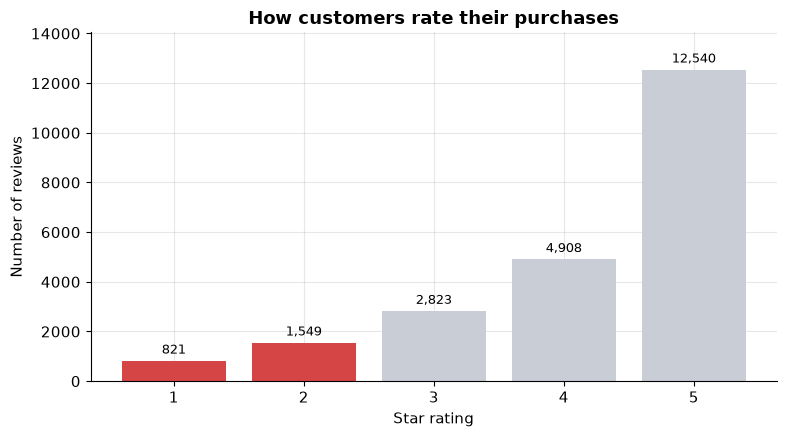

In [6]:
rating_counts = df["Rating"].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=["#d64545" if r <= 2 else "#c9ced6" for r in rating_counts.index])
ax.bar_label(bars, labels=[f"{v:,}" for v in rating_counts.values], padding=3, fontsize=9)
ax.set_title("How customers rate their purchases", fontweight="bold")
ax.set_xlabel("Star rating")
ax.set_ylabel("Number of reviews")
ax.set_ylim(0, rating_counts.max() * 1.12)
plt.tight_layout()
plt.show()

Most people are happy: 4 and 5 stars completely dominate. The 1 and 2 star reviews are
the two red bars, and they are clearly a minority. That is reassuring, because it means the
"critical" pile is small enough to handle with care rather than drown in.

### Are the bad reviews spread evenly across departments?

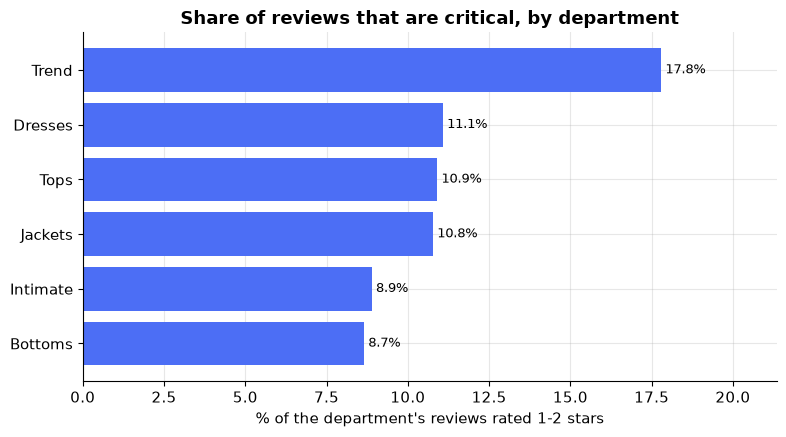

In [7]:
df["is_critical"] = df["Rating"].isin([1, 2])
by_dept = (df.groupby("Department Name")["is_critical"].mean()
             .mul(100).sort_values())

fig, ax = plt.subplots()
bars = ax.barh(by_dept.index, by_dept.values, color="#4c6ef5")
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in by_dept.values], padding=3, fontsize=9)
ax.set_title("Share of reviews that are critical, by department", fontweight="bold")
ax.set_xlabel("% of the department's reviews rated 1-2 stars")
ax.set_xlim(0, by_dept.max() * 1.2)
plt.tight_layout()
plt.show()

Not even. Some departments run noticeably hotter than others. That is already useful
before I have written a single reply: if one product line makes more customers unhappy, that
is where the buying team should look first.

## 4. Isolating the critical reviews

Here is the core rule, and it is deliberately boring: a review is "critical" if it was rated
1 or 2 stars. No model, no threshold to tune, just a filter. This is the "no machine
learning" part the brief asked for.

In [8]:
critical = df[df["Rating"].isin([1, 2])].copy()
print(f"{len(critical):,} critical reviews "
      f"({len(critical) / len(df) * 100:.1f}% of everything).")
critical[["Rating", "Department Name", "Review Text"]].head()

2,370 critical reviews (10.5% of everything).


,Rating,Department Name,Review Text
5,2,Dresses,"I love tracy reese dresses, but this one is no..."
22,2,Dresses,"First of all, this is not pullover styling. th..."
26,2,Tops,I have been waiting for this sweater coat to s...
33,2,Tops,"I ordered this 3 months ago, and it finally ca..."
56,2,Intimate,I am pregnant and i thought this would be a gr...


## 5. What are people actually complaining about?

A rating tells me a review is bad, but not *why*. To get the why, I count the words that
show up most often across the critical reviews.

Raw word counts are mostly filler ("the", "and", "it"), so I strip those out with a
small stopword list I wrote by hand. I kept it visible on purpose: the brief asks for basic
string work, so I would rather you see exactly what I am removing than bury it inside a
library like NLTK. My first pass was still full of empty words like "like", "back" and "one",
so I kept growing the list until the words left standing actually meant something. I also
drop a few dataset-specific words, mainly `retailer` (the brand name was anonymised to that
word in the data) and plain garment words like `dress` that are everywhere and say nothing
about the complaint itself.

In [9]:
# A short, hand-written stopword list. Common filler plus a few words that are
# everywhere in this particular dataset and tell me nothing about the complaint.
stopwords = set((
    "a an the this that these those i you he she it we they me my your his her its our their "
    "is am are was were be been being do does did have has had will would can could should "
    "and or but if then so because as of at by for with about to from in on into over under "
    "not no just very really too also more most much many than there here what which who when "
    "where why how all any both each few other some such only own same s t im ive "
    # a second pass of empty words that showed up in my first word count
    "like likes back look looks looked looking love loved loves out one ones even way ways "
    "get got want wanted know knew think thought made make making go going went still though "
    "well overall bit little lot around able say said thing things need really them "
    # leftover stems after stripping apostrophes (didn't -> didn t, doesn't -> doesn t)
    "didn don doesn wasn weren aren isn wouldn couldn shouldn wont cant dont thats "
    # dataset-specific noise
    "retailer dress top shirt fabric size sizes wear worn ordered order review reviews"
).split())

def top_words(texts, n=20):
    counts = Counter()
    for t in texts:
        for w in t.split():
            if len(w) > 2 and w not in stopwords:
                counts[w] += 1
    return counts.most_common(n)

top_keywords = top_words(critical["clean_text"], n=20)
keywords_df = pd.DataFrame(top_keywords, columns=["word", "count"])
keywords_df

,word,count
0,fit,687
1,small,518
2,material,428
3,color,380
4,quality,339
5,large,302
6,cute,293
7,sweater,276
8,great,268
9,tried,259


### The complaint words, as a chart

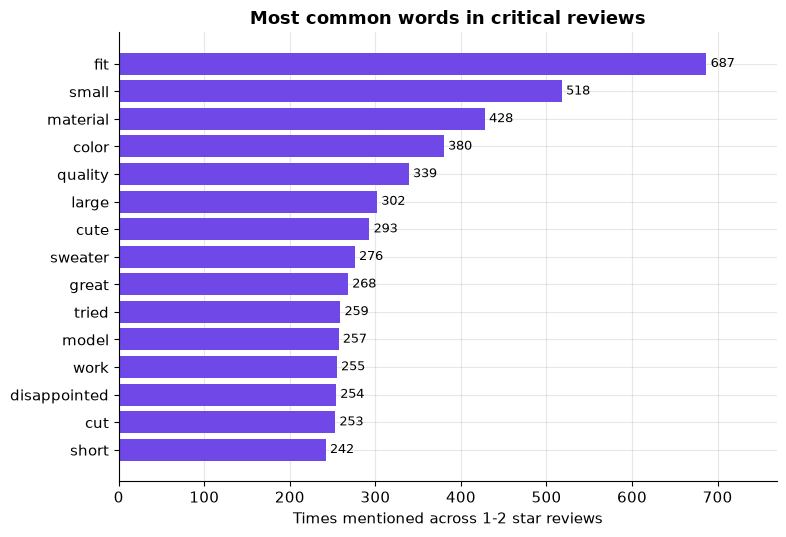

In [10]:
top15 = keywords_df.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(top15["word"], top15["count"], color="#7048e8")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Most common words in critical reviews", fontweight="bold")
ax.set_xlabel("Times mentioned across 1-2 star reviews")
ax.set_xlim(0, top15["count"].max() * 1.12)
plt.tight_layout()
plt.show()

### Two-word phrases give better context

Single words lose meaning fast. "Small" on its own could be "runs small" or "not small". So
I also counted two-word phrases, and this time I keep the little words like "too" and "not",
because that is exactly where the meaning lives.

In [11]:
phrase_stopwords = stopwords - {"not", "too", "very", "so"}

def top_phrases(texts, n=15):
    counts = Counter()
    for t in texts:
        words = [w for w in t.split() if len(w) > 2 and w not in phrase_stopwords]
        for a, b in zip(words, words[1:]):
            counts[f"{a} {b}"] += 1
    return counts.most_common(n)

pd.DataFrame(top_phrases(critical["clean_text"]), columns=["phrase", "count"])

,phrase,count
0,not flattering,106
1,too big,82
2,very disappointed,73
3,see through,73
4,too short,67
5,too small,60
6,not sure,58
7,too bad,55
8,not worth,50
9,too tight,50


### Grouping the words into themes

Thirty separate words is hard to act on. I was curious whether they would fall into a few
obvious buckets, so I sorted the common complaints into themes by hand and counted how many
critical reviews land in each. A review can count toward more than one theme, which feels
right, since people complain about several things at once.

In [12]:
themes = {
    "Fit & sizing":     ["small", "large", "tight", "loose", "big", "petite",
                         "runs", "fit", "sizing", "boxy", "narrow"],
    "Quality":          ["quality", "cheap", "cheaply", "material", "thin", "flimsy",
                         "poorly", "seam", "seams", "fell", "apart", "itchy"],
    "Look vs. photo":   ["color", "colour", "looked", "picture", "photo",
                         "different", "online", "shape", "weird"],
    "Price":            ["price", "priced", "expensive", "overpriced", "worth", "money"],
    "Shipping":         ["late", "shipping", "delivery", "delayed", "arrived", "package"],
    "Returns/service":  ["return", "returned", "refund", "exchange", "service"],
}

def count_themes(texts, theme_map):
    rows = []
    for name, words in theme_map.items():
        words = set(words)
        hits = sum(any(w in set(t.split()) for w in words) for t in texts)
        rows.append((name, hits, round(hits / len(texts) * 100, 1)))
    return (pd.DataFrame(rows, columns=["theme", "reviews", "pct_of_critical"])
              .sort_values("reviews", ascending=False)
              .reset_index(drop=True))

themes_df = count_themes(critical["clean_text"], themes)
themes_df

,theme,reviews,pct_of_critical
0,Fit & sizing,1316,55.5
1,Look vs. photo,1069,45.1
2,Quality,936,39.5
3,Returns/service,383,16.2
4,Price,253,10.7
5,Shipping,131,5.5


### The themes, as a chart

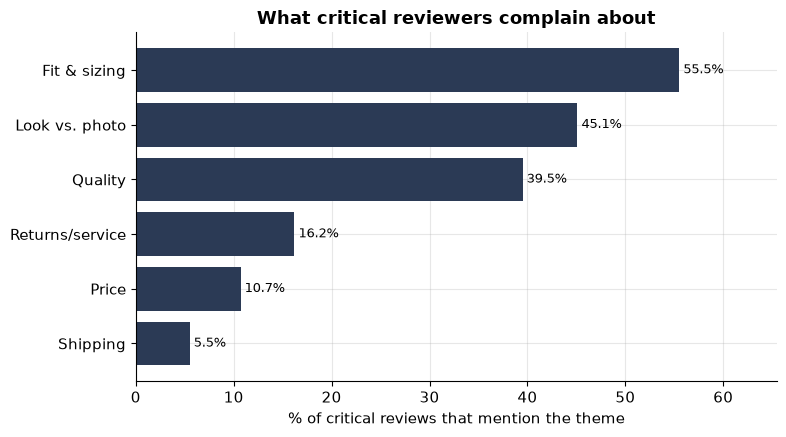

In [13]:
order = themes_df.iloc[::-1]

fig, ax = plt.subplots()
bars = ax.barh(order["theme"], order["pct_of_critical"], color="#2b3a55")
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in order["pct_of_critical"]],
             padding=3, fontsize=9)
ax.set_title("What critical reviewers complain about", fontweight="bold")
ax.set_xlabel("% of critical reviews that mention the theme")
ax.set_xlim(0, order["pct_of_critical"].max() * 1.18)
plt.tight_layout()
plt.show()

Fit and sizing runs away with it, followed by quality. That actually makes sense:
those are the two things you genuinely cannot judge from a product photo, so they are where
online clothing disappoints people most.

## 6. Which reviews should we reply to first?

I cannot hand-write replies to all of these, and the point is to prioritise. Not every
1-star review is equally urgent. I want the ones that are:

- the lowest rated (1 star),
- detailed enough that there is a real, specific complaint to answer, and
- upvoted by other shoppers, because a complaint lots of people agreed with does the most
  damage if it is left sitting there.

So I take the 1-star reviews, keep the reasonably long ones, and sort by how many "positive
feedback" votes they picked up.

In [14]:
detailed = critical[(critical["Rating"] == 1) &
                    (critical["Review Text"].str.len() > 250)]
top3 = detailed.sort_values("Positive Feedback Count", ascending=False).head(3)
top3[["Positive Feedback Count", "Department Name", "Review Text"]]

,Positive Feedback Count,Department Name,Review Text
7493,108,Jackets,"I generally don't write bad reviews, but there..."
17839,48,Dresses,Do not buy this dress for full price. the desi...
12061,43,Tops,"There were no reviews, it's an ""online exclusi..."


## 7. Drafting the replies with a language model

Now the Gen AI part. For each of those three reviews I ask a model to write a short, actually
apologetic reply that names the customer's specific problem and signs off from StyleNest.

I am using **OpenRouter**, which lets me reach a lot of models through one endpoint, and I am
sticking to a free one. The key just goes in a plain variable below. If you are re-running
this, drop your own key in from <https://openrouter.ai/keys>.

In [15]:
API_KEY = "PASTE-YOUR-OPENROUTER-KEY-HERE"   # OpenRouter, free tier

# The free models get busy and throw rate-limit errors, so I keep a few and try each.
MODELS = [
    "google/gemma-4-26b-a4b-it:free",
    "meta-llama/llama-3.3-70b-instruct:free",
    "qwen/qwen3-next-80b-a3b-instruct:free",
    "google/gemma-4-31b-it:free",
    "meta-llama/llama-3.2-3b-instruct:free",
]

Most of the quality comes from the prompt. I tell the model who it is, ask it to name
the specific problem instead of a vague "sorry for your experience", and to offer one real
next step. I also tell it not to invent order numbers, because models love making those up.

In [16]:
def write_reply(review_text):
    system = (
        "You are Aria, a friendly customer support agent at StyleNest, an online "
        "women's clothing shop. A customer left an unhappy review. Write a short apology "
        "email of about 120-150 words that opens with real empathy, names the specific "
        "problem the customer mentioned, takes responsibility without excuses, and offers "
        "one clear next step (a refund or a replacement). Keep it warm and human, no "
        "corporate jargon, and do not invent order numbers. Start with a 'Subject:' line "
        "and sign off as Aria, Customer Care, StyleNest."
    )
    payload = {
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": f'The review:\n"{review_text}"'},
        ],
        "temperature": 0.7,
    }
    # try each model, and if they are all busy wait a moment and go round again
    for _ in range(6):
        for model in MODELS:
            r = requests.post(
                "https://openrouter.ai/api/v1/chat/completions",
                headers={"Authorization": f"Bearer {API_KEY}"},
                json={**payload, "model": model},
                timeout=60,
            )
            if r.status_code == 200:
                data = r.json()
                if "choices" in data:   # a 200 can still carry an error body
                    return data["choices"][0]["message"]["content"].strip(), model
        time.sleep(10)
    raise RuntimeError("Every free model is rate-limited right now. Try again in a minute.")

And now the actual run: three reviews in, three drafted replies out.

In [17]:
drafts = []
for i, (_, row) in enumerate(top3.iterrows(), start=1):
    reply, model = write_reply(row["Review Text"])
    drafts.append({"n": i, "department": row["Department Name"],
                   "review": row["Review Text"], "model": model, "reply": reply})
    display(Markdown(
        f"### Reply {i}\n"
        f"*{row['Department Name']} &nbsp;·&nbsp; drafted by* `{model}`\n\n"
        f"**Original review**\n\n> {row['Review Text']}\n\n"
        f"**Drafted reply**\n\n{reply}\n\n---"
    ))

### Reply 1
*Jackets &nbsp;·&nbsp; drafted by* `google/gemma-4-31b-it:free`

**Original review**

> I generally don't write bad reviews, but there is a real discrepancy between the quality of this kimono and the cost. the design and colors are great, but the fabric is ripping on all the kimonos on the rack in my store where the manufacturer's tag is at the back of the neck. the material is very thin, so there are other small holes beginning throughout the garment. i shop at retailer all the time, and this is not a $98 item of clothing.

**Drafted reply**

Subject: We're so sorry about your kimonos

Hi there,

I was truly sorry to read about the issues you're experiencing with our kimonos. It sounds incredibly frustrating to love the design and colors, only to find the fabric ripping at the neckline and developing holes. Please accept my sincerest apologies; this is not the level of quality we strive for, and it's clear we missed the mark here.

You deserve garments that last, especially at that price point, and I take full responsibility for this disappointment. I want to make this right for you immediately. Would you prefer a full refund for the damaged items, or would you like us to send out high-quality replacements?

Just let me know which option works best for you, and I will handle the rest.

Warmly,

Aria, Customer Care, StyleNest

---

### Reply 2
*Dresses &nbsp;·&nbsp; drafted by* `google/gemma-4-26b-a4b-it:free`

**Original review**

> Do not buy this dress for full price. the design looks great but after receiving the dress, the material is made of extremely cheap slinky-ish polyester that you would find at a f21 store. the stitching is horrific and created an uneven "hump" on the back seam. just absolutely poor poor quality.

**Drafted reply**

Subject: We’re so sorry about your recent experience

Hi there,

I am so incredibly sorry that the dress you ordered didn't live up to the beautiful design you saw online. I can completely understand your frustration; when you invest in a piece from StyleNest, you expect high-quality fabric and flawless craftsmanship, not cheap material and uneven stitching. 

It sounds like we truly missed the mark with the quality control on this item, and I take full responsibility for that disappointment. This is certainly not the standard we strive for.

I want to make this right for you immediately. I would love to offer you a full refund for the dress so you can shop somewhere else that meets your expectations. Please just reply to this email letting me know if you'd prefer the refund or a free replacement sent via express shipping.

Warmly,

Aria
Customer Care, StyleNest

---

### Reply 3
*Tops &nbsp;·&nbsp; drafted by* `google/gemma-4-26b-a4b-it:free`

**Original review**

> There were no reviews, it's an "online exclusive" and thought it might look good with a nice skirt at an upcoming wedding. the spandex jersey back looks like sweat shirt material. on the white version of this, it is mismatched with an oatmeal color and white that just looks awful. as a busty 36d i was stunned to find myself swimming in a medium. it does not look like the photograph and the sleeve billow out. i feel like this had to have been clipped and tucked in for this photograph. i'm an anth

**Drafted reply**

Subject: We're so sorry about your recent order

Hi there,

I am so incredibly sorry to hear that your recent purchase fell so short of your expectations. I can completely understand your disappointment; when you are preparing for a special wedding, the last thing you want is to receive an item that feels more like sweatshirt material than elegant evening wear.

It sounds like the color mismatch between the white and oatmeal tones was upsetting, and I sincerely apologize that the sizing and sleeve fit didn't match our website photographs. We clearly missed the mark on representing the true fit and fabric of this piece.

I want to make this right for you immediately. Please let me know if you would prefer a full refund to your original payment method or a replacement in a different size and color.

Warmly,

Aria, Customer Care, StyleNest

---

### Saving the replies as Word documents

In real life an agent opens these in Word, tweaks a line, and hits send. So as a last step I
save each reply as its own `.docx` file in an `emails/` folder. If `python-docx` is not
installed, the cell just says so and moves on instead of breaking the run.

In [18]:
try:
    from docx import Document
except ImportError:
    print("To save the Word files, install python-docx first:  pip install python-docx")
else:
    import os
    os.makedirs("emails", exist_ok=True)
    for d in drafts:
        doc = Document()
        doc.add_heading(f"StyleNest Customer Care - Reply {d['n']}", level=1)
        doc.add_paragraph(f"Department: {d['department']}    Drafted by: {d['model']}").runs[0].italic = True
        doc.add_paragraph("Original review:").runs[0].bold = True
        doc.add_paragraph(d["review"]).runs[0].italic = True
        doc.add_paragraph("")
        for line in d["reply"].split("\n"):
            line = line.strip()
            if not line:
                continue
            p = doc.add_paragraph(line)
            if line.lower().startswith("subject:"):
                p.runs[0].bold = True
        filename = f"emails/Reply_{d['n']}_{d['department'].replace('/', '-')}.docx"
        doc.save(filename)
        print("Saved", filename)

Saved emails/Reply_1_Jackets.docx
Saved emails/Reply_2_Dresses.docx
Saved emails/Reply_3_Tops.docx


## 8. What I found, and what I would do next

A few things stood out to me:

- Only about **1 in 10** reviews is critical, so automating just that slice is realistic.
  The team can keep replying by hand everywhere the tone is already positive.
- The complaints are not random noise. They cluster hard around **fit/sizing** and
  **quality**, which are exactly the two things you cannot judge from a photo.
- The three drafted replies came out genuinely specific. They mention the real problem
  rather than a generic apology, so with a human giving each one a quick read before it
  goes out, this would cut a lot of the cold-start writing the support team does today.

If I had more time, I would:

- Break the complaint themes down per department, so the findings feed back to the buying
  team and not just customer support.
- Add a quick automated check on each drafted email before a human sees it.
- Try two or three different models on the same review and compare how the tone reads.

---

Thanks for reading. - Hiral